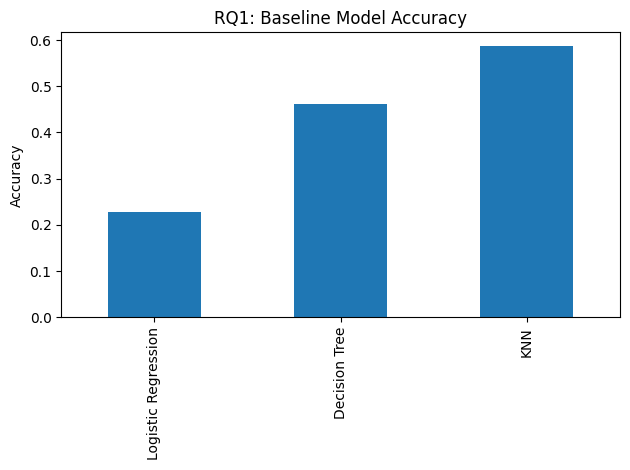


Files saved in: C:\Users\vishwa\kidney disease prediction/outputs/


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("kidney_disease_balanced.csv")

# Replace '?' with NaN (VERY IMPORTANT)
df.replace('?', np.nan, inplace=True)


# =========================
# 2. SEPARATE TARGET
# =========================
y = df["Target"]
X = df.drop("Target", axis=1)


# =========================
# 3. HANDLE CATEGORICAL + NUMERIC SEPARATELY
# =========================
cat_cols = X.select_dtypes(include=['str']).columns
num_cols = X.select_dtypes(exclude=['str']).columns


# =========================
# 4. IMPUTE MISSING VALUES
# =========================
# Numerical
num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Categorical
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])


# =========================
# 5. ENCODE CATEGORICAL
# =========================
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])


# Encode target
y = LabelEncoder().fit_transform(y)


# =========================
# 6. SCALE
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)


# =========================
# 7. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 8. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, average='weighted'),
    recall_score(y_test, y_pred, average='weighted'),
    f1_score(y_test, y_pred, average='weighted')
]
    


# =========================
# 9. SAVE TABLE
# =========================
df_out = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-score"]
).T

df_out.to_csv("RQ1_table.csv")


# =========================
# 10. SAVE FIGURE
# =========================
plt.figure()
df_out["Accuracy"].plot(kind="bar")
plt.title("RQ1: Baseline Model Accuracy")
plt.ylabel("Accuracy")
plt.tight_layout()

plt.savefig("RQ1_figure.pdf")
plt.show()
print("\nFiles saved in:", os.getcwd() + "/outputs/")